In [19]:
import os
import sys
from pathlib import Path
import cv2 as cv
import matplotlib.pyplot as plt
from tqdm import tqdm
from  sort_roboflow_dataset_train_test_valid import sort_dataset, create_data_yaml, create_split_index, apply_split
import shutil

In [20]:
COMBINATIONS_BASE_FOLDER = Path("/home/samuel/test/MasterThesis/Orthomosaics/band_combinations/float_combinations")

OUTPUT_FOLDER = Path("/home/samuel/test/MasterThesis/Orthomosaics/band_combinations/float_combinations/full_datasets")

os.makedirs(OUTPUT_FOLDER, exist_ok=True)

LABELS_LRGE_FOLDER = Path("/home/samuel/Downloads/Bjornkjaervej_TestFlight_2_bigger")
LABELS_MID_FOLDER = Path("/home/samuel/Downloads/Bjornkjaervej_TestFlight_2_mid")
LABELS_SMALL_FOLDER = Path("/home/samuel/Downloads/Bjornkjaervej_TestFlight_2_small")
LABELS_FOLDERS = [LABELS_LRGE_FOLDER, LABELS_MID_FOLDER, LABELS_SMALL_FOLDER]


folders = ["large", "mid", "small"]

combinations = os.listdir(COMBINATIONS_BASE_FOLDER / folders[0])
print(combinations)


['RED_GREEN_NIR']


In [33]:
# change all classes to 0 in all label files
for label_folder in LABELS_FOLDERS:
    label_folder_name = Path(label_folder).name
    label_folder = Path(label_folder) / "train" / "labels"
    print(f"Renaming labels in folder: {label_folder_name}")
    for label_file in os.listdir(label_folder):
        if label_file.endswith(".txt"):
            contents = ""
            with open(label_folder / label_file, "r") as f:
                for line in f:
                    parts = line.strip().split()
                    parts[0] = "0"  # Change class to 0
                    contents += " ".join(parts) + "\n"
            with open(label_folder / label_file, "w") as f:
                f.write(contents)

Renaming labels in folder: Bjornkjaervej_TestFlight_2_bigger
Renaming labels in folder: Bjornkjaervej_TestFlight_2_mid
Renaming labels in folder: Bjornkjaervej_TestFlight_2_small


In [34]:
# rename label files 

label_folder_name = None

for label_folder in LABELS_FOLDERS:
    label_folder_name = Path(label_folder).name
    label_folder = Path(label_folder) / "train" / "labels"
    print(f"Renaming labels in folder: {label_folder_name}")
    for label_file in os.listdir(label_folder):
        if label_file.endswith(".txt"):
            index = label_file.rfind("_NEN")
            base_name = label_file[:index]
            print(base_name)
            new_label_file = f"{label_folder_name}_{base_name}.txt"
            os.rename(label_folder / label_file, label_folder / new_label_file)


Renaming labels in folder: Bjornkjaervej_TestFlight_2_bigger
tile_15_2
tile_19_6
tile_37_1
tile_25_6
tile_24_10
tile_22_10
tile_30_10
tile_2_5
tile_31_12
tile_26_12
tile_33_3
tile_36_9
tile_3_11
tile_23_12
tile_12_8
tile_34_12
tile_13_2
tile_39_1
tile_6_6
tile_34_2
tile_22_12
tile_35_1
tile_11_3
tile_20_4
tile_12_3
tile_21_6
tile_38_11
tile_11_10
tile_30_7
tile_2_12
tile_1_9
tile_12_6
tile_19_9
tile_20_12
tile_28_10
tile_23_2
tile_33_12
tile_16_7
tile_25_3
tile_31_4
tile_6_13
tile_8_5
tile_34_1
tile_36_2
tile_39_9
tile_8_9
tile_4_11
tile_6_7
tile_2_7
tile_2_9
tile_32_4
tile_38_3
tile_8_8
tile_28_8
tile_33_5
tile_10_12
tile_14_10
tile_27_4
tile_20_10
tile_26_1
tile_26_4
tile_30_9
tile_18_5
tile_30_2
tile_17_2
tile_24_3
tile_20_6
tile_29_2
tile_7_11
tile_33_10
tile_7_6
tile_10_3
tile_7_4
tile_19_4
tile_37_11
tile_5_6
tile_33_2
tile_18_2
tile_34_8
tile_36_10
tile_23_11
tile_39_2
tile_31_13
tile_33_1
tile_9_7
tile_23_6
tile_19_13
tile_12_4
tile_35_3
tile_25_7
tile_8_4
tile_5_3
tile_4_4
til

In [35]:
# rename image files 

label_folder_name = None

for label_folder in LABELS_FOLDERS:
    label_folder_name = Path(label_folder).name
    label_folder = Path(label_folder) / "train" / "images"
    print(f"Renaming labels in folder: {label_folder_name}")
    for label_file in os.listdir(label_folder):
        if label_file.endswith(".jpg"):
            index = label_file.rfind("_NEN")
            base_name = label_file[:index]
            print(base_name)
            new_label_file = f"{label_folder_name}_{base_name}.jpg"
            os.rename(label_folder / label_file, label_folder / new_label_file)


Renaming labels in folder: Bjornkjaervej_TestFlight_2_bigger
tile_3_9
tile_28_5
tile_3_10
tile_26_7
tile_38_4
tile_40_8
tile_7_6
tile_26_10
tile_28_11
tile_15_9
tile_12_3
tile_18_3
tile_14_2
tile_26_3
tile_7_3
tile_15_8
tile_17_5
tile_29_10
tile_36_7
tile_31_8
tile_1_12
tile_33_11
tile_34_10
tile_1_8
tile_13_8
tile_3_8
tile_25_12
tile_11_10
tile_5_3
tile_11_11
tile_5_7
tile_37_6
tile_6_10
tile_12_9
tile_6_11
tile_39_8
tile_18_8
tile_8_2
tile_10_11
tile_22_4
tile_17_6
tile_38_7
tile_36_9
tile_13_11
tile_35_2
tile_29_3
tile_6_7
tile_5_11
tile_14_13
tile_11_2
tile_16_6
tile_32_5
tile_10_5
tile_27_6
tile_14_6
tile_11_6
tile_35_5
tile_21_2
tile_26_8
tile_26_9
tile_32_7
tile_10_10
tile_23_6
tile_7_9
tile_29_12
tile_15_10
tile_10_6
tile_30_8
tile_19_3
tile_9_7
tile_8_8
tile_25_2
tile_14_3
tile_21_10
tile_5_9
tile_2_13
tile_17_7
tile_30_3
tile_39_12
tile_40_12
tile_4_13
tile_10_13
tile_30_4
tile_30_13
tile_8_6
tile_15_11
tile_37_1
tile_31_10
tile_30_10
tile_15_5
tile_40_7
tile_8_13
tile_37_5
t

In [8]:
extension = ".png"

In [9]:
large_combo_root = COMBINATIONS_BASE_FOLDER / "large"
label_dir = LABELS_LRGE_FOLDER / "train" / "labels"

combos_roots = [COMBINATIONS_BASE_FOLDER / "large", COMBINATIONS_BASE_FOLDER / "mid", COMBINATIONS_BASE_FOLDER / "small"]
label_dirs = [LABELS_LRGE_FOLDER / "train" / "labels",LABELS_MID_FOLDER / "train" / "labels",LABELS_SMALL_FOLDER / "train" / "labels"]


In [10]:
from pathlib import Path
import os


for index, combo_all in enumerate(combos_roots):

    labels = [
        lbl.replace(".txt", "")
        for lbl in os.listdir(label_dirs[index])
        if lbl.endswith(".txt")
    ]
    
    for combo in os.listdir(combo_all):
        combo_path = combo_all / combo
        print(f"\nProcessing combo: {combo}")

        for large_image in os.listdir(combo_path):
            if not large_image.endswith(extension):
                continue

            underscore_indices = [i for i, c in enumerate(large_image) if c == "_"]
            if len(underscore_indices) < 3:
                print(f"  Skipping {large_image} (not enough underscores)")
                continue

            third_underscore_index = underscore_indices[2]
            base_name = large_image[:third_underscore_index]
            print(f"  Base name extracted: {base_name}")

            matched = False

            for label_name in labels:
                if label_name.endswith(base_name):
                    new_name = f"{label_name}{extension}"

                    print(f"  ✓ Renaming {large_image} → {new_name}")
                    os.rename(
                        combo_path / large_image,
                        combo_path / new_name
                    )

                    matched = True
                    break

            if not matched:
                print(f"  ✗ No label match → removing {large_image}")
                os.remove(combo_path / large_image)



Processing combo: RED_GREEN_NIR
  Base name extracted: tile_24_15
  ✗ No label match → removing tile_24_15_EXTEND_RED_GREEN_NIR.png
  Base name extracted: tile_7_0
  ✗ No label match → removing tile_7_0_EXTEND_RED_GREEN_NIR.png
  Base name extracted: tile_13_14
  ✗ No label match → removing tile_13_14_EXTEND_RED_GREEN_NIR.png
  Base name extracted: tile_7_15
  ✗ No label match → removing tile_7_15_EXTEND_RED_GREEN_NIR.png
  Base name extracted: tile_27_15
  ✗ No label match → removing tile_27_15_EXTEND_RED_GREEN_NIR.png
  Base name extracted: tile_41_2
  ✗ No label match → removing tile_41_2_EXTEND_RED_GREEN_NIR.png
  Base name extracted: tile_10_9
  ✓ Renaming tile_10_9_EXTEND_RED_GREEN_NIR.png → Bjornkjaervej_TestFlight_2_bigger_tile_10_9.png
  Base name extracted: tile_32_4
  ✓ Renaming tile_32_4_EXTEND_RED_GREEN_NIR.png → Bjornkjaervej_TestFlight_2_bigger_tile_32_4.png
  Base name extracted: tile_15_0
  ✗ No label match → removing tile_15_0_EXTEND_RED_GREEN_NIR.png
  Base name ext

In [11]:
# create new full datasets folder
new_full_dataset_folder = COMBINATIONS_BASE_FOLDER / "full_datasets"
os.makedirs(new_full_dataset_folder, exist_ok=True)


large_combo_root = COMBINATIONS_BASE_FOLDER / "large"
for combo in os.listdir(large_combo_root):
    combo_path = large_combo_root / combo
    print(f"\nProcessing combo: {combo}")

    new_dataset_path = new_full_dataset_folder / combo
    os.makedirs(new_dataset_path / "images", exist_ok=True)
    os.makedirs(new_dataset_path / "labels", exist_ok=True)

for index, combo_all in enumerate(combos_roots):

    for combo in os.listdir(combo_all):
        combo_path = combo_all / combo
        print(f"\nProcessing combo: {combo}")

        new_dataset_path = new_full_dataset_folder / combo

        for image_file in os.listdir(combo_path):
            if image_file.endswith(extension):
                shutil.copy2(
                    combo_path / image_file,
                    new_dataset_path / "images" / image_file
                )

        label_dir = label_dirs[index]

        for label_file in os.listdir(label_dir):
            if label_file.endswith(".txt"):
                shutil.copy2(
                    label_dir / label_file,
                    new_dataset_path / "labels" / label_file
                )


Processing combo: RED_GREEN_NIR

Processing combo: RED_GREEN_NIR

Processing combo: RED_GREEN_NIR

Processing combo: RED_GREEN_NIR


In [13]:
# split datasets into identical train, test, valid
import json

train_percent = 0.70
valid_percent = 0.25
test_percent = 0.10
extension = ".png"
seed = 3


datasets = os.listdir(OUTPUT_FOLDER)

for entry in os.listdir(OUTPUT_FOLDER):
    if not os.path.isdir(OUTPUT_FOLDER / entry):
        datasets.remove(entry)

first = datasets[0]

split = create_split_index(
    OUTPUT_FOLDER  / first / "images",
    OUTPUT_FOLDER / first / "labels",
    seed=seed,
    train_pct=train_percent,
    val_pct=valid_percent,
    test_pct=test_percent,
    extension=extension
)

print(f"Created split with {len(split['train'])} train, {len(split['val'])} val, {len(split['test'])} test samples.")


with open(OUTPUT_FOLDER / "split.json", "w") as f:
    json.dump(split, f, indent=2)

print(f"Saved split to {OUTPUT_FOLDER / 'split.json'}")

for dataset in datasets:
    dataset_path = OUTPUT_FOLDER / dataset
    print(f"Applying split to dataset: {dataset}")
    apply_split(dataset_path , dataset_path / "data", OUTPUT_FOLDER / "split.json", extension=extension)

# create dataset yaml files
for dataset in datasets:
    dataset_path = OUTPUT_FOLDER / dataset / "data"
    print(f"Creating dataset yaml for: {dataset}")
    create_data_yaml(
        dataset_path,
        classes=["Potato"]
    )

Total samples found: 881
Created split with 616 train, 220 val, 45 test samples.
Saved split to /home/samuel/test/MasterThesis/Orthomosaics/band_combinations/float_combinations/full_datasets/split.json
Applying split to dataset: RED_GREEN_NIR
Creating dataset yaml for: RED_GREEN_NIR
Created dataset.yaml at /home/samuel/test/MasterThesis/Orthomosaics/band_combinations/float_combinations/full_datasets/RED_GREEN_NIR/data/dataset.yaml


In [1]:
import geopandas as gpd
from shapely.affinity import rotate

import rasterio
from rasterio.warp import reproject, Resampling
from rasterio.transform import Affine
import math
import numpy as np


def rotate_raster(src_path, dst_path, angle_deg):
    with rasterio.open(src_path) as src:
        data = src.read()
        profile = src.profile.copy()
        transform = src.transform
        crs = src.crs
        h, w = src.height, src.width

    cx, cy = w / 2, h / 2

    rot = (
        Affine.translation(cx, cy)
        * Affine.rotation(angle_deg)
        * Affine.translation(-cx, -cy)
    )

    new_transform = transform * rot

    out = np.zeros_like(data)

    reproject(
        source=data,
        destination=out,
        src_transform=transform,
        src_crs=crs,
        dst_transform=new_transform,
        dst_crs=crs,
        resampling=Resampling.bilinear
    )

    profile.update(transform=new_transform)

    with rasterio.open(dst_path, "w", **profile) as dst:
        dst.write(out)



def rotate_vectors(src_vec, dst_vec, angle_deg):
    gdf = gpd.read_file(src_vec)

    center = gdf.total_bounds
    cx = (center[0] + center[2]) / 2
    cy = (center[1] + center[3]) / 2

    gdf["geometry"] = gdf.geometry.apply(
        lambda g: rotate(g, angle_deg, origin=(cx, cy))
    )

    gdf.to_file(dst_vec)

def geom_to_yolo(geom, tile_bounds):
    minx, miny, maxx, maxy = geom.bounds
    tb_minx, tb_miny, tb_maxx, tb_maxy = tile_bounds

    cx = ((minx + maxx) / 2 - tb_minx) / (tb_maxx - tb_minx)
    cy = ((miny + maxy) / 2 - tb_miny) / (tb_maxy - tb_miny)
    w = (maxx - minx) / (tb_maxx - tb_minx)
    h = (maxy - miny) / (tb_maxy - tb_miny)

    return cx, cy, w, h

from rasterio.windows import Window

def tile_raster(src_path, tile_size):
    with rasterio.open(src_path) as src:
        for y in range(0, src.height, tile_size):
            for x in range(0, src.width, tile_size):
                window = Window(x, y, tile_size, tile_size)
                transform = src.window_transform(window)
                data = src.read(window=window)

                yield data, transform, window

def clip_vectors_to_tile(gdf, tile_bounds):
    return gdf.clip(tile_bounds)

def geom_to_yolo(geom, tile_bounds):
    minx, miny, maxx, maxy = geom.bounds
    tb_minx, tb_miny, tb_maxx, tb_maxy = tile_bounds

    cx = ((minx + maxx) / 2 - tb_minx) / (tb_maxx - tb_minx)
    cy = ((miny + maxy) / 2 - tb_miny) / (tb_maxy - tb_miny)
    w = (maxx - minx) / (tb_maxx - tb_minx)
    h = (maxy - miny) / (tb_maxy - tb_miny)

    return cx, cy, w, h


rotate_raster(
    "/home/samuel/test/MasterThesis/Orthomosaics/20250827_Bjornkjaervej_TestFlight_2_small.tif",
    "/home/samuel/test/MasterThesis/Orthomosaics/20250827_Bjornkjaervej_TestFlight_2_small_rot45.tif",
    angle_deg=45
)

rotate_vectors(
    "/home/samuel/test/MasterThesis/Orthomosaics/shape_files/t.gpkg",
    "/home/samuel/test/MasterThesis/Orthomosaics/shape_files/annotations_rot45.gpkg",
    angle_deg=45
)

data, transform, window = next(tile_raster(
    "/home/samuel/test/MasterThesis/Orthomosaics/20250827_Bjornkjaervej_TestFlight_2_small_rot45.tif",
    tile_size=1024
))

bounds = rasterio.windows.bounds(window, transform)

cliped_vectors = clip_vectors_to_tile(
    gpd.read_file("/home/samuel/test/MasterThesis/Orthomosaics/shape_files/annotations_rot45.gpkg"),
    bounds
)

for idx, row in cliped_vectors.iterrows():
    yolo_box = geom_to_yolo(row.geometry, bounds)
    print(f"YOLO box: {yolo_box}")
#!/usr/bin/env python3

: 

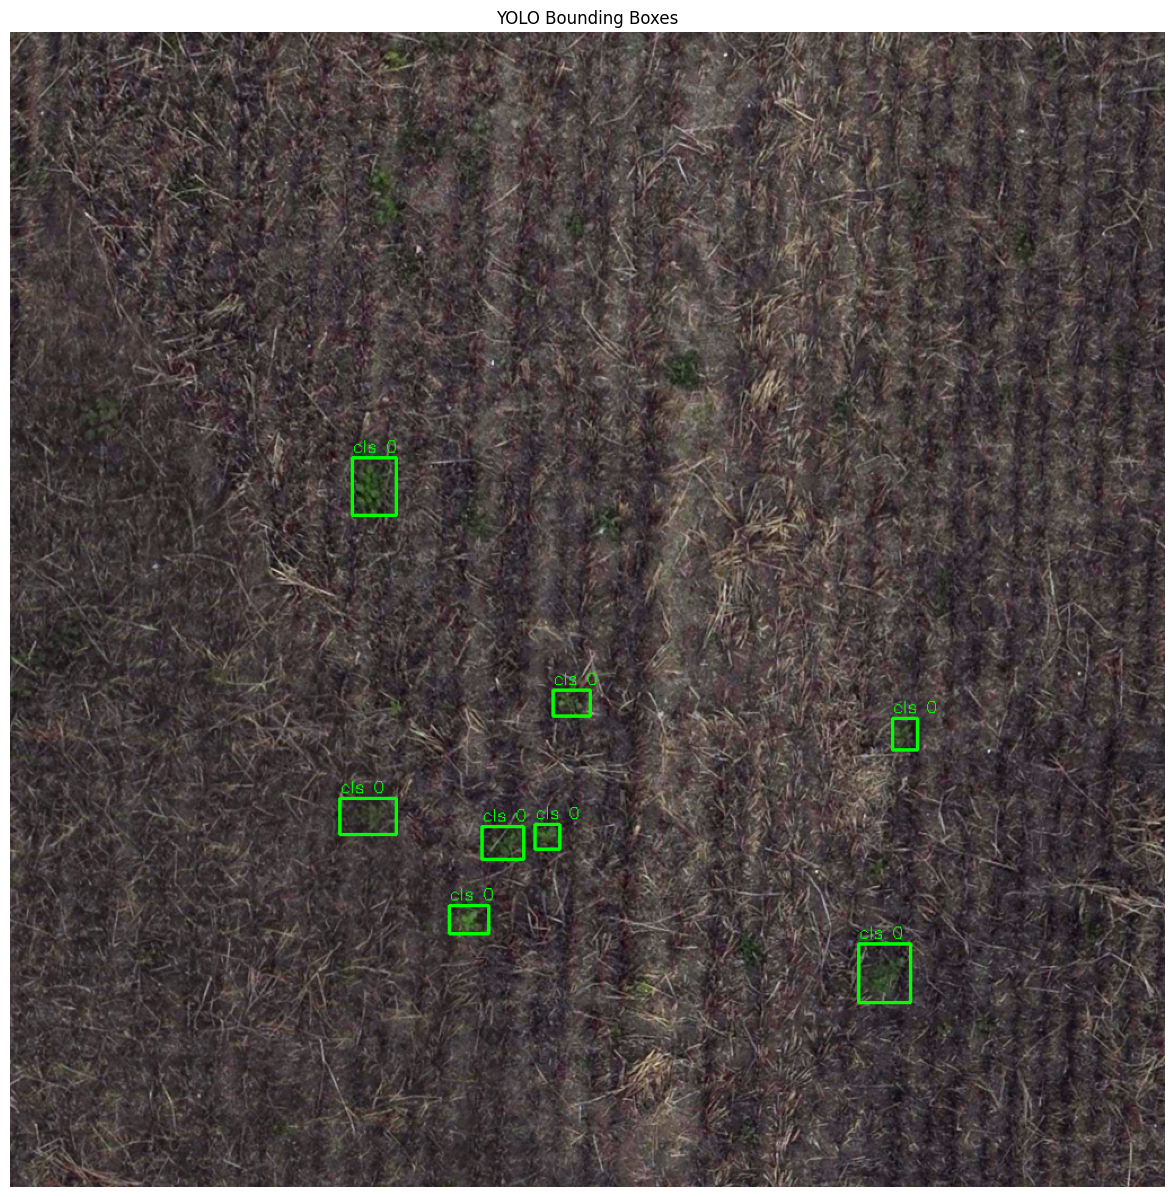

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------
# Paths
# ------------------------------
image_path = "/home/samuel/test/MasterThesis/Orthomosaics/translated/processed_output/nir/tile_1_1_NIR.png"
label_path = "/home/samuel/test/MasterThesis/Orthomosaics/shape_files/ground_truth/tile_1_1.txt"

# ------------------------------
# Load image
# ------------------------------
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w = img.shape[:2]

# ------------------------------
# Load YOLO labels and draw boxes
# ------------------------------
with open(label_path, "r") as f:
    for line in f:
        parts = line.strip().split()
        cls = int(parts[0])

        x_c, y_c, bw, bh = map(float, parts[1:5])

        # Convert normalized → pixel coordinates
        x_c *= w
        y_c *= h
        bw *= w
        bh *= h

        x1 = int(x_c - bw / 2)
        y1 = int(y_c - bh / 2)
        x2 = int(x_c + bw / 2)
        y2 = int(y_c + bh / 2)

        # Draw rectangle
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

        # Optional: draw class label
        cv2.putText(
            img,
            f"cls {cls}",
            (x1, max(y1 - 5, 0)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0, 255, 0),
            1
        )

# ------------------------------
# Show result
# ------------------------------
plt.figure(figsize=(15, 15))
plt.imshow(img)
plt.title("YOLO Bounding Boxes")
plt.axis("off")
plt.show()
